In [372]:
# displays static in notebook
#%matplotlib inline  

# functions for file handling
import re as re
import os as os
from glob import glob

# math and stats
import numpy as np
from astropy.stats import sigma_clipped_stats
from astropy import units as u
from astropy.coordinates import SkyCoord  # High-level coordinates
from astropy.time import Time

from astropy.wcs import WCS

import cv2
from skimage import data, color
from skimage.registration import phase_cross_correlation
from skimage.registration._phase_cross_correlation import _upsampled_dft
from scipy.ndimage import fourier_shift
from skimage.transform import warp_polar, rotate, rescale, warp_coords, AffineTransform, warp

# point source identification and photometry
from photutils.detection import DAOStarFinder
from photutils.psf import PSFPhotometry

# graphics and plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# I/O
from astropy.io import fits
import requests
from pathlib import Path
import sys, getopt,os
from glob import glob
import shutil

# point source identification and photometry
from photutils.detection import DAOStarFinder
from photutils.psf import PSFPhotometry



from astropy.table import Table,vstack, unique
import matplotlib as mpl
import numpy as np
import pandas as pd
import json
from pathlib import Path
from glob import glob
from slugify import slugify
import argparse
#import arabic_reshaper
from bidi.algorithm import get_display



In [364]:
def split_text_in_middle(tmp_str):
    midpoint=len(tmp_str)/2
    word_list=tmp_str.split(' ')
    length_vec=[len(x) for x in word_list]
    split_point_diff=[np.abs(sum(length_vec[0:x])-midpoint) for x in range(0,len(length_vec))]
    split_point=split_point_diff.index(min(split_point_diff))
    for index,word in enumerate(word_list):
        if index==0:
           output_str=word
        elif index!=split_point:
            output_str=output_str+' '+word
        else:
            output_str=output_str+'\n'+word
    return output_str

def split_text_at_character(tmp_str,split_char=' ',reverse=False):
    if reverse:
        split_pos=tmp_str.find(split_char)
    else:
        split_pos=tmp_str.rfind(split_char)
    if split_pos<0:
        return tmp_str
    else:
        if tmp_str[split_pos-1]==' ':
            return tmp_str[0:split_pos-1]+'\n'+tmp_str[split_pos:]
        elif split_char==' ':
            return tmp_str[0:split_pos]+'\n'+tmp_str[split_pos+1:]
        else:    
            return tmp_str[0:split_pos]+'\n'+tmp_str[split_pos:]

def rgb_from_spt_teff(teff,data_table):
    tmp_ind=np.argmin(abs(data_table['T_eff']-teff))
    rgb=[data_table['R'][tmp_ind],data_table['G'][tmp_ind],data_table['B'][tmp_ind]]
    return rgb
def rgb_from_bb_teff(teff,data_table):
    tmp_ind=np.argmin(abs(data_table['T_eff']-teff))
    rgb=[data_table['R'][tmp_ind],data_table['G'][tmp_ind],data_table['B'][tmp_ind]]
    return rgb
def rgb_from_teff_logg(teff,logg,data_table,teff_values,logg_values):
    tmp_ind1=np.argmin(abs(teff_values-teff))
    tmp_ind2=np.argmin(abs(logg_values-logg))
    mask = (data_table['T_eff']==teff_values[tmp_ind1]) & (data_table['logg']==logg_values[tmp_ind2])
    
    tmp_table=data_table[mask]
    if len(tmp_table)>0:
        
        rgb=[tmp_table['R'][0],tmp_table['G'][0],tmp_table['B'][0]]
    else:
        rgb=[1,1,1]
    return rgb

def font_loader(possible_fonts):
    usable_fonts=[]
    #find any fonts in the font folder of package and load them
    #packaged_fonts_path = Path(__file__).parent / 'fonts/*ttf'
    packaged_fonts_path = './fonts/*ttf'
    packaged_font_files=glob(str(packaged_fonts_path))
    for font_file in packaged_font_files:
        font_manager.fontManager.addfont(font_file)
    loaded_font_list=[f.name for f in font_manager.fontManager.ttflist]
    #loop over fonts for the required script and add any that are available to the list of fonts to pass to matplotlib
    for font in possible_fonts:
        if font in loaded_font_list:
            usable_fonts.append(font)
    if "Noto Sans" in loaded_font_list:
        usable_fonts.append("Noto Sans") #add Noto Sans font as backup
    if "Arial Unicode" in loaded_font_list:
        usable_fonts.append("Arial Unicode") #add Arial Unicode font as backup
    if "DejaVu Sans" in loaded_font_list:
        usable_fonts.append("DejaVu Sans") #add default matplotlib font as backupNotoSans
    plt.rcParams['font.family']=usable_fonts #pass fonts to matplotlib


def filesWith(folder,subs):
    files = []
    times = np.array([])

    with os.scandir(folder) as dir_contents:
        for entry in dir_contents:
            files.append(entry.name)        
        
    print(len(files), ' files in folder ', folder)
    
    res = [i for i in files if subs in i]
    
    return res



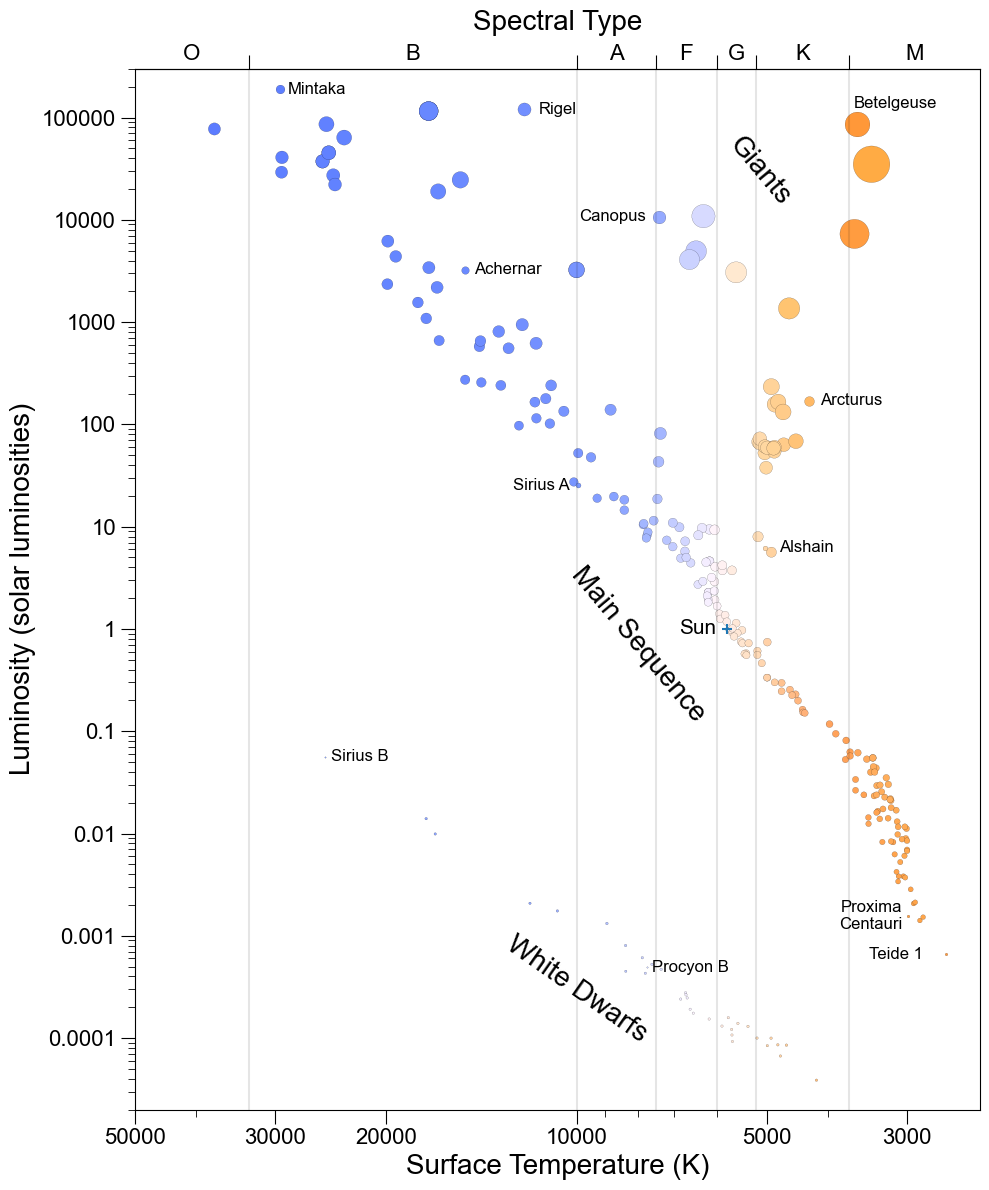

In [342]:
outfile_base = './plots/'


translations_path = './translations/translations.json'
translations_file = open(translations_path)
translations_dicts = json.load(translations_file)
translations_file.close()

language_code = 'en'
text_list=translations_dicts[language_code]
possible_fonts=text_list['possible_fonts']

text_vertical_factor=1.0
#important that arabic reshaper comes before bidi get_display
if language_code.startswith('ar'):
    text_list = {key:(arabic_reshaper.reshape(value) if type(value)==str else value) for key, value in text_list.items()}
elif language_code.startswith('kr') or language_code.startswith('jp') or language_code.startswith('zh'):
    text_vertical_factor=0.9 #this is added as CJK fonts seemed to make the luminosity class labels a bit too high in position

text_list = {key:(get_display(value) if type(value)==str else value) for key, value in text_list.items()}

#check is cairo is required and load matplotlib
if text_list["matplotlib_cairo"]:
    import mplcairo
import matplotlib as mpl
if text_list["matplotlib_cairo"]:
    mpl.use("module://mplcairo.qt")
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib import font_manager
from matplotlib import cm
from matplotlib.lines import Line2D
from matplotlib.patches import CirclePolygon,Circle
from matplotlib.collections import PolyCollection,RegularPolyCollection

text_list_en=translations_dicts['en']
font_loader(possible_fonts)



#load in input data from the various input files
#pickles_data = Table.read(Path(__file__).parent / "./data/pickles1998.vot")
pickles_data = Table.read('./data/pickles1998.vot')
filtered_data1=pickles_data['teff_gspphot','luminosity','radius_gspphot','logg_gspphot']
filtered_data1['teff_gspphot'].name = 'teff'
filtered_data1['radius_gspphot'].name = 'radius'
filtered_data1['logg_gspphot'].name = 'logg'
#bright_nearby_data = Table.read(Path(__file__).parent / "./data/bright_nearby_stars_sample.vot")
bright_nearby_data = Table.read('./data/bright_nearby_stars_sample.vot')
filtered_data2=bright_nearby_data['teff_gspphot','luminosity','radius_gspphot','logg_gspphot']
filtered_data2['teff_gspphot'].name = 'teff'
filtered_data2['radius_gspphot'].name = 'radius'
filtered_data2['logg_gspphot'].name = 'logg'

#nearby_data = Table.read(Path(__file__).parent / "./data/nearby_stars_sample.vot")
nearby_data = Table.read('./data/nearby_stars_sample.vot')
filtered_data3=nearby_data['teff_gspphot','luminosity','radius_gspphot','logg_gspphot']
filtered_data3['teff_gspphot'].name = 'teff'
filtered_data3['radius_gspphot'].name = 'radius'
filtered_data3['logg_gspphot'].name = 'logg'

#wd_data = Table.read(Path(__file__).parent / "./data/vincent2024_nearby_white_dwarfs.vot")
wd_data = Table.read('./data/vincent2024_nearby_white_dwarfs.vot')
wd_data['radius']=10.0**wd_data['logR']
wd_data['luminosity']=10.0**wd_data['logL']
filtered_data4=wd_data['teff','luminosity','radius','logg']
filtered_data=vstack([filtered_data1,filtered_data2,filtered_data3,filtered_data4],metadata_conflicts='silent')

#load named star data
#named_stars_data=Table.read(Path(__file__).parent / "./data/named_stars.vot")
named_stars_data=Table.read('./data/named_stars.vot')

#read in colour data from Harre & Heller tables
#harre_heller_2021_t1_data = Table.read(Path(__file__).parent / "./data/harre_heller_2021_t1.csv")
#harre_heller_2021_t2_data = Table.read(Path(__file__).parent / "./data/harre_heller_2021_t2.csv")
#harre_heller_2021_t5_data = Table.read(Path(__file__).parent / "./data/harre_heller_2021_t5.csv")
harre_heller_2021_t1_data = Table.read('./data/harre_heller_2021_t1.csv')
harre_heller_2021_t2_data = Table.read('./data/harre_heller_2021_t2.csv')
harre_heller_2021_t5_data = Table.read('./data/harre_heller_2021_t5.csv')
teff_values=sorted(list(set(harre_heller_2021_t2_data['T_eff'])))
logg_values=sorted(list(set(harre_heller_2021_t2_data['logg'])))
colours_tmp=[]

#loop over nearby star data + white dwarfs and add RGB colours to each star
for row in filtered_data:
    if row['logg']>5.5 or not row['logg']:
        #if it's a white dwarf use blackbody relation
        colour_tmp=rgb_from_bb_teff(row['teff'],harre_heller_2021_t1_data)
    elif row['teff']>10000:
        #if its a hot star use just Teff to colour
        colour_tmp=rgb_from_spt_teff(row['teff'],harre_heller_2021_t5_data)
    else:
        colour_tmp=rgb_from_teff_logg(row['teff'],row['logg'],harre_heller_2021_t2_data,teff_values,logg_values)
    colours_tmp.append([colour_tmp])
filtered_data.add_column(colours_tmp, name='colour')

fig, ax1 = plt.subplots(figsize=(10, 12))

ax1.axis([50000,2000,0.00001,1000000.0])

# add regions for spectral types
ax2_major = [3700, 5200, 6000, 7500, 10000, 33000]
ylims = ax1.get_ylim()
for i in range(len(ax2_major)):
    ax1.plot([ax2_major[i], ax2_major[i]], ylims, c='black', alpha=0.1)


ax1.scatter(filtered_data['teff'],filtered_data['luminosity'],
           s=30.0*np.sqrt(filtered_data['radius']),marker='o',c=filtered_data['colour'],edgecolor='k',linewidths=0.1)


#loop over named star data and add RGB colours to each star or white dwarf
for  row in named_stars_data:
    if row['literature_logg']>5.5:
        #if it's a white dwarf use blackbody relation
        colour_tmp=rgb_from_bb_teff(row['literature_effective_temperature'],harre_heller_2021_t1_data)
    elif row['literature_effective_temperature']>10000 or not row['literature_logg']:
        #if its a hot star or has no gravity estimate use just Teff to colour
        colour_tmp=rgb_from_spt_teff(row['literature_effective_temperature'],harre_heller_2021_t5_data)
    else:
        colour_tmp=rgb_from_teff_logg(row['literature_effective_temperature'],row['literature_logg'],
                                      harre_heller_2021_t2_data,teff_values,logg_values)
    scatter_tmp=plt.scatter(row['literature_effective_temperature'],row['literature_luminosity'],
                            s=10.0*np.sqrt(row['radius_used']),marker='o',c=[colour_tmp],edgecolor='k',linewidths=0.1)
    if row['text_offset_x']>1.0:
        ha_tmp='right'
    else:
        ha_tmp='left'
    """
    if row['text_offset_y']>1.0:
        va_tmp='bottom'
    else:
        va_tmp='top'
    """
    text_tmp=text_list[slugify(row['english_name']+'-name')]
    if len(text_tmp)>12:
        index_tmp=row['english_name'].rfind(' ')
        text_tmp=text_tmp[:index_tmp]+'\n'+text_tmp[index_tmp+1:]
    starFont = 12
    xOffset = 0
    yOffset = 0
    if text_tmp == 'Sun':
        starFont = 15
        xOffset = 0
    if text_tmp == 'Teide 1':
        xOffset = 900
    if text_tmp == 'Kelu-1 A':
        text_tmp = ''
    if text_tmp == 'Betelgeuse':
        xOffset = 400
        yOffset = 50000
    plt.text(row['text_offset_x']*row['literature_effective_temperature']+xOffset,
             row['literature_luminosity']+yOffset,
             text_tmp,ha=ha_tmp,va='center',fontsize=starFont)

# add special marker at the sun
ax1.scatter([5772], [1], marker='+', s=50)

#plt.xlabel(text_list['xaxis_text'], fontsize=20)
plt.xlabel('Surface Temperature (K)', fontsize=20)
plt.ylabel(text_list['yaxis_text'], fontsize=20)
plt.xscale('log')
#plt.yscale('log')
ax1.set_yscale('log')

#plt.title(text_list['title_text'])
plt.xticks([50000.0,30000.0,20000.0, 10000.0,5000.0,3000.0,2000.0],
           [50000,30000,20000, 10000,5000,3000,2000], fontsize=16)
plt.yticks([1E-5,1E-4, 1E-3, 1E-2, 1E-1, 1, 10, 100, 1000, 10000, 100000],
           ['0.00001', '0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000', '100000'], fontsize=16)
ax1.tick_params(axis='both', which='major', length=10)
ax1.tick_params(axis='both', which='minor', length=5)
plt.tick_params(axis='y', which='minor')

#locmin = ticker.LogLocator(base=10.0,subs=(0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8),numticks=12)
locmin = ticker.LogLocator(base=10.0,subs=np.arange(0.1, 1, 0.1),numticks=12)
ax1.yaxis.set_minor_locator(locmin)
ax1.yaxis.set_minor_formatter(ticker.NullFormatter())
ax1.set_ylim(2E-5, 3E5)
ax1.set_xlim(2300, 50000)
ax1.invert_xaxis()

# add Spectral Type region labels
ax2 = ax1.secondary_xaxis('top')
ax2.set_xlabel('Spectral Type', fontsize=20, labelpad=10)
#ax2.set_xticks([2000,3000,5000, 10000, 20000], ['M', 'K', 'G', 'A', 'B'])
ax2.set_xticks(ax2_major)
ax2.xaxis.set_major_formatter(ticker.NullFormatter())
ax2_ticks = ax2_major
ax2_ticks = np.append(2300, ax2_ticks)
ax2_ticks = np.append(ax2_ticks, 50000)
#print(ax2_ticks)
#print(np.roll(ax2_ticks, -1))
ax2_minor = np.sqrt(ax2_ticks * np.roll(ax2_ticks,-1))
#print(ax2_minor)
ax2_minor = ax2_minor[:-1]
#print(ax2_minor)
ax2.xaxis.set_minor_locator(ticker.FixedLocator(ax2_minor))
ax2.xaxis.set_minor_formatter(ticker.FixedFormatter(['M', 'K', 'G', 'F', 'A', 'B', 'O']))
#ax2.tick_params(axis='x', labelsize=30)
ax2.invert_xaxis()
ax2.tick_params(axis='both', which='major', length=10)
ax2.tick_params(axis='both', which='minor', length=0, labelsize=16)


#add the labels for luminosity classes
ax1.text(10000.0,text_vertical_factor*0.0003,text_list['wd_text'],rotation=-35,ha='center',va='center', fontsize=20)
ax1.text(8000.0,text_vertical_factor*0.7,text_list['ms_text'],rotation=-50,ha='center',va='center', fontsize=20)
#ax.text(5000.0,text_vertical_factor*4,text_list['sbg_text'],rotation=-35,ha='center',va='center', fontsize=15)
#ax.text(5300.0,text_vertical_factor*100,text_list['g_text'],rotation=-15,ha='right',va='center', fontsize=15)
ax1.text(4500.0,text_vertical_factor*30000,text_list['g_text'],rotation=-50,ha='right',va='center', fontsize=20)
#plt.text(5300.0,text_vertical_factor*3000,text_list['bg_text'],rotation=0,ha='left',va='center')
#ax.text(6000.0,text_vertical_factor*100000,text_list['spg_text'],rotation=0,ha='center',va='center', fontsize=15)
#ax.text(2010.0,text_vertical_factor*0.000035,split_text_in_middle(text_list['bd_text']),rotation=0,ha='right',va='center', fontsize=15)
handles=[]
legends=[]
for i0 in range(0,6):
    radius_tmp=pow(10.0,3-i0)
    handles.append(Line2D([], [], color='white', marker='o',markersize=np.sqrt(20.0*np.sqrt(radius_tmp)), markerfacecolor=None,markeredgecolor='k',markeredgewidth=0.1))
    if radius_tmp>1:
        legends.append(str(int(radius_tmp)))
    else:
        legends.append(str(radius_tmp))
#add the legend
if '(' in text_list['rad_text']:
    rad_legend=split_text_at_character(text_list['rad_text'],split_char='(')
else:
    rad_legend=split_text_in_middle(text_list['rad_text'])
#leg=plt.legend(handles,legends,loc="lower left", title=rad_legend,fontsize=6,title_fontsize=8,labelspacing=1.5)
#plt.setp(leg.get_title(), multialignment='center')
filename_tmp=text_list['filename']

#plt.show()
fig.tight_layout()

#print('Saving to: '+str(outfile_base.joinpath(filename_tmp+'_'+str.lower(language_code)+'.'+str.lower(args.output_format))))
#plt.savefig(str(outfile_base.joinpath(filename_tmp+'_'+str.lower(language_code)+'.'+str.lower(args.output_format))))
plt.savefig('HR-diagram-modified.jpg')


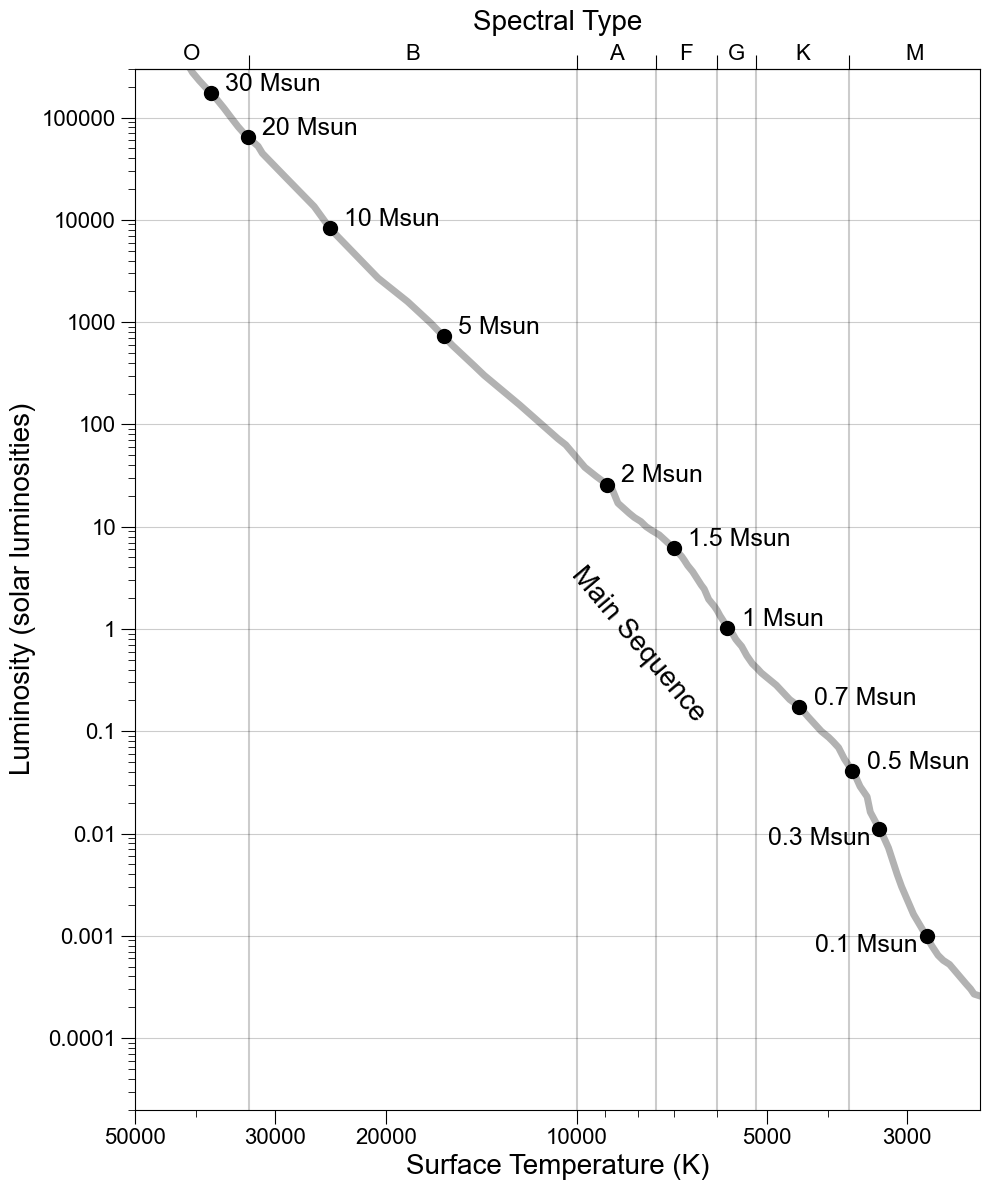

In [536]:
# same format graph, but without actual stars
# overlay L, T from Mamajek 2022
# "A Modern Mean Dwarf Stellar Color and Effective Temperature Sequence"
# http://www.pas.rochester.edu/~emamajek/EEM_dwarf_UBVIJHK_colors_Teff.txt



fig, ax1 = plt.subplots(figsize=(10, 12))

ax1.axis([50000,2000,0.00001,1000000.0])

# add regions for spectral types
ax2_major = [3700, 5200, 6000, 7500, 10000, 33000]
ylims = ax1.get_ylim()
for i in range(len(ax2_major)):
    ax1.plot([ax2_major[i], ax2_major[i]], ylims, c='black', alpha=0.2)

#plt.xlabel(text_list['xaxis_text'], fontsize=20)
plt.xlabel('Surface Temperature (K)', fontsize=20)
plt.ylabel(text_list['yaxis_text'], fontsize=20)
plt.xscale('log')
#plt.yscale('log')
ax1.set_yscale('log')

#plt.title(text_list['title_text'])
plt.xticks([50000.0,30000.0,20000.0, 10000.0,5000.0,3000.0,2000.0],
           [50000,30000,20000, 10000,5000,3000,2000], fontsize=16)
plt.yticks([1E-5,1E-4, 1E-3, 1E-2, 1E-1, 1, 10, 100, 1000, 10000, 100000],
           ['0.00001', '0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000', '100000'], fontsize=16)
ax1.tick_params(axis='both', which='major', length=10)
ax1.tick_params(axis='both', which='minor', length=5)
plt.tick_params(axis='y', which='minor')

#locmin = ticker.LogLocator(base=10.0,subs=(0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8),numticks=12)
locmin = ticker.LogLocator(base=10.0,subs=np.arange(0.1, 1, 0.1),numticks=12)
ax1.yaxis.set_minor_locator(locmin)
ax1.yaxis.set_minor_formatter(ticker.NullFormatter())
ax1.set_ylim(2E-5, 3E5)
ax1.set_xlim(2300, 50000)
ax1.invert_xaxis()
ax1.grid(which='major', axis='y', c='black', alpha=0.2)

# add Spectral Type region labels
ax2 = ax1.secondary_xaxis('top')
ax2.set_xlabel('Spectral Type', fontsize=20, labelpad=10)
#ax2.set_xticks([2000,3000,5000, 10000, 20000], ['M', 'K', 'G', 'A', 'B'])
ax2.set_xticks(ax2_major)
ax2.xaxis.set_major_formatter(ticker.NullFormatter())
ax2_ticks = ax2_major
ax2_ticks = np.append(2300, ax2_ticks)
ax2_ticks = np.append(ax2_ticks, 50000)
#print(ax2_ticks)
#print(np.roll(ax2_ticks, -1))
ax2_minor = np.sqrt(ax2_ticks * np.roll(ax2_ticks,-1))
#print(ax2_minor)
ax2_minor = ax2_minor[:-1]
#print(ax2_minor)
ax2.xaxis.set_minor_locator(ticker.FixedLocator(ax2_minor))
ax2.xaxis.set_minor_formatter(ticker.FixedFormatter(['M', 'K', 'G', 'F', 'A', 'B', 'O']))
#ax2.tick_params(axis='x', labelsize=30)
ax2.invert_xaxis()
ax2.tick_params(axis='both', which='major', length=10)
ax2.tick_params(axis='both', which='minor', length=0, labelsize=16)

#add the labels for luminosity classes
ax1.text(8000.0,text_vertical_factor*0.7,text_list['ms_text'],rotation=-50,ha='center',va='center', fontsize=20)

#ax1.plot([2000, 3600, 50000], [0.00001, 0.06, 500000], c='black', alpha=0.3, lw=15)

inFile = 'Mass_Teff_LogL.csv'
mass, Teff, LogL = np.loadtxt(inFile, unpack = True, delimiter=',')
ax1.plot(Teff, 10**LogL, c='black', alpha=0.3, lw=5)

massSort = np.argsort(mass)

#labelMasses = np.array([0.1, 0.5, 1, 2, 5, 10, 20, 50])
labelMasses = [0.1, 0.3, 0.5, 0.7, 1, 1.5, 2, 5, 10, 20, 30]
labelTeff = 10**np.interp(labelMasses, mass[massSort], np.log10(Teff[massSort]))
labelLogL = np.interp(labelMasses, mass[massSort], LogL[massSort])
ax1.scatter(labelTeff, 10**labelLogL, c='black', s=100)
#print(labelMasses, labelTeff, 10**labelLogL)
for i in range(len(labelMasses)):
    x, y = 0.95*labelTeff[i], 1.05*10**labelLogL[i]
    if (labelMasses[i] < 0.4):
        x, y = 1.5*labelTeff[i], 0.7*10**labelLogL[i]

    ax1.annotate(str(labelMasses[i]) + ' Msun', (x, y), fontsize=18)



#plt.show()
fig.tight_layout()

#print('Saving to: '+str(outfile_base.joinpath(filename_tmp+'_'+str.lower(language_code)+'.'+str.lower(args.output_format))))
#plt.savefig(str(outfile_base.joinpath(filename_tmp+'_'+str.lower(language_code)+'.'+str.lower(args.output_format))))
plt.savefig('HR-diagram-schematic.jpg')


In [439]:
#scrap section

In [441]:
# adapted from read_mist_models.py

def read_iso_file(infile):
    #open file and read it in
    with open(infile) as f:
        content = [line.split() for line in f]
    version = {'MIST': content[0][-1], 'MESA': content[1][-1]}
    abun = {content[3][i]:float(content[4][i]) for i in range(1,5)}
    rot = float(content[4][-1])
    num_ages = int(content[6][-1])
          
    #read one block for each isochrone
    iso_set = []
    ages = []
    counter = 0
    data = content[8:]
    for i_age in range(num_ages):
        #grab info for each isochrone
        num_eeps = int(data[counter][-2])
        num_cols = int(data[counter][-1])
        hdr_list = data[counter+2][1:]
        formats = tuple([np.int32]+[np.float64 for i in range(num_cols-1)])
        iso = np.zeros((num_eeps),{'names':tuple(hdr_list),'formats':tuple(formats)})
        #read through EEPs for each isochrone
        for eep in range(num_eeps):
            iso_chunk = data[3+counter+eep]
            iso[eep]=tuple(iso_chunk)
        iso_set.append(iso)
        ages.append(iso[0][1])
        counter+= 3+num_eeps+2
    return version, abun, rot, ages, num_ages, hdr_list, iso_set  

def age_index(ages, age):
    diff_arr = abs(np.array(ages) - age)
    age_index = np.where(diff_arr == min(diff_arr))[0][0]
    
    if ((age > max(ages)) | (age < min(ages))):
        print('The requested age is outside the range. Try between ' + str(min(ages)) + ' and ' + str(max(ages)))
       
    return age_index
 

In [443]:
# load MESA files 
#  standard grid from https://waps.cfa.harvard.edu/MIST/interp_isos.html

#inFolder = '/Users/geoffmathews/Dropbox/References/MIST/MIST_v1.2_vvcrit0.0_full_isos/'
inFolder = '/Users/geoffmathews/Dropbox/References/MIST/'
ifilelist = glob(inFolder+'*.iso')
print(ifilelist)

version, abun, rot, ages, num_ages, hdr_list, iso_set = read_iso_file(ifilelist[0])
print('Versione: ', version)
print('Abundance, rotation: ', abun, rot)
print('number of ages, ages: ', num_ages, ages)
print('headers: ', hdr_list)



['/Users/geoffmathews/Dropbox/References/MIST/MIST_iso_68223a6975514.iso']
Versione:  {'MIST': '1.2', 'MESA': '7503'}
Abundance, rotation:  {'Yinit': 0.271, 'Zinit': 0.014649, '[Fe/H]': 0.01, '[a/Fe]': 0.0} 0.4
number of ages, ages:  107 [5.0, 5.05, 5.1, 5.15, 5.2, 5.25, 5.3, 5.35, 5.4, 5.45, 5.5, 5.55, 5.6, 5.65, 5.7, 5.75, 5.8, 5.8500000000000005, 5.9, 5.95, 6.0, 6.050000000000001, 6.1000000000000005, 6.15, 6.2, 6.25, 6.300000000000001, 6.3500000000000005, 6.4, 6.45, 6.5, 6.550000000000001, 6.6000000000000005, 6.65, 6.7, 6.75, 6.800000000000001, 6.8500000000000005, 6.9, 6.95, 7.0, 7.050000000000001, 7.1000000000000005, 7.15, 7.200000000000001, 7.25, 7.300000000000001, 7.3500000000000005, 7.4, 7.450000000000001, 7.5, 7.550000000000001, 7.6000000000000005, 7.65, 7.700000000000001, 7.75, 7.800000000000001, 7.8500000000000005, 7.9, 7.950000000000001, 8.0, 8.05, 8.100000000000001, 8.15, 8.200000000000001, 8.25, 8.3, 8.350000000000001, 8.4, 8.450000000000001, 8.5, 8.55, 8.600000000000001, 

Age Index:  0
Age Index:  20
Age Index:  40
Age Index:  60
Age Index:  80


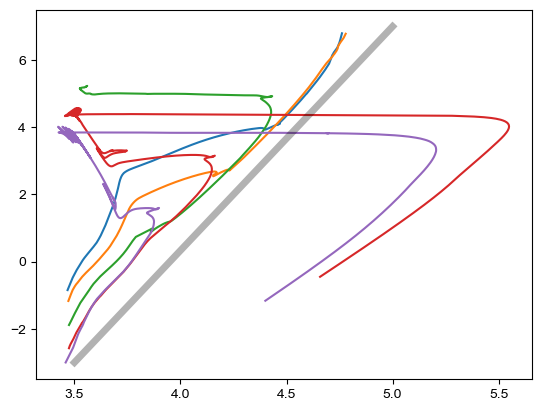

In [444]:
for i in range(5,10):
    age_ind = age_index(ages, i)
    print('Age Index: ', age_ind)
    logTeff = iso_set[age_ind]['log_Teff']
    logL = iso_set[age_ind]['log_L']
    plt.plot(logTeff, logL) #plot the HR diagram for logage = 8.0

plt.plot([3.5, 5],[-3, 7], c='black', alpha=0.3, lw=5)


In [450]:
# select ZAMS for each mass
# Primary EEP 2, EEP Number 202

print(iso_set[age_ind]['initial_mass'])


[0.1008217  0.1043685  0.10904671 ... 2.32558056 2.32674888 2.32814114]
